## Naive Bayes on IMDB (Action, Romance, Horror) Data - Multilabel

## Imports

In [1]:
import os
import sys
import re
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from models.multilabel_naive_bayes import MultilabelNaiveBayes
from utils.preprocessing import clean_text
from utils.evaluation import evaluate_multilabel_model

from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MultiLabelBinarizer
from lime.lime_text import LimeTextExplainer
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

## Filepaths

In [3]:
#Paths to CSVs
BASE_DIR = r"C:\Users\rebec\Duke\ECE684\FilmGenreClassification\data\imdb_arh_trimmed"

TRAIN_CSV = os.path.join(BASE_DIR, "imdb_arh_train.csv")
VAL_CSV   = os.path.join(BASE_DIR, "imdb_arh_val.csv")
TEST_CSV  = os.path.join(BASE_DIR, "imdb_arh_test.csv")

#Naive Bayes hyperparams
ALPHA = 1.0            # Laplace smoothing

#Preprocessing options
REMOVE_STOPWORDS = False  #set True to remove stopwords

## Helper Functions

### Multilabel Data Processing

In [6]:
class IMDBDataset(Dataset):
    def __init__(self, data_dir_path, filename, class_names, text_col='description', label_col='genre_list'):
        """
        Args:
            data_dir_path (Path or str): Relative path to data directory.
            filename (str): The CSV filename (e.g., 'train.csv').
            class_names (list): List of valid classes (ORDER MATTERS).
            text_col (str): Column name for text.
            label_col (str): Column name for labels.
        """
        # 1. Setup Path safely
        self.data_path = Path(data_dir_path) / filename
        
        if not self.data_path.exists():
            raise FileNotFoundError(f"File not found at: {self.data_path.resolve()}")
            
        print(f"Loading data from {self.data_path.name}...")
        self.df = pd.read_csv(self.data_path)
        
        # 2. Process Text (Handle NaNs, ensure strings)
        self.texts = self.df[text_col].fillna("").astype(str).tolist()
        
        # 3. Process Labels (Multi-hot Encoding)
        # Create map: "Action" -> 0, "Drama" -> 1, etc.
        self.class_to_idx = {cls: i for i, cls in enumerate(class_names)}
        self.num_classes = len(class_names)
        self.labels = []
        
        # Track unseen genres for safety warning
        unseen_genres = set()
        
        for genre_str in self.df[label_col]:
            # Initialize zero vector [0.0, 0.0, ...]
            label_vec = torch.zeros(self.num_classes, dtype=torch.float)
            
            if pd.notna(genre_str):
                # Split "Action, Drama" -> ["Action", "Drama"]
                # .strip() removes whitespace around words
                current_genres = [g.strip() for g in str(genre_str).split(',')]
                
                for genre in current_genres:
                    if genre in self.class_to_idx:
                        idx = self.class_to_idx[genre]
                        label_vec[idx] = 1.0
                    else:
                        # Track genres that don't match our class list
                        unseen_genres.add(genre)
            
            self.labels.append(label_vec)

        # 4. Warning System
        # If this is the test set, and it has weird genres not in train, warn the user.
        if unseen_genres:
            print(f"⚠️  WARNING in {filename}: Found {len(unseen_genres)} genres not in the provided class list.")
            print(f"   Examples of ignored genres: {list(unseen_genres)[:5]}")
            print(f"   (These were ignored during label creation)")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

    @staticmethod
    def discover_classes(data_dir_path, filename, label_col='genre_list'):
        """
        Static utility to scan a CSV and return sorted unique class names.
        Use this ONCE on your TRAINING set only.
        """
        path = Path(data_dir_path) / filename
        if not path.exists():
             raise FileNotFoundError(f"File not found at: {path.resolve()}")

        df = pd.read_csv(path)
        
        # Split by comma, explode list to rows, strip whitespace, find unique
        genres = df[label_col].dropna().astype(str).str.split(',').explode().str.strip().unique()
        
        return sorted(list(genres))

### Load Dataset

In [8]:
def load_multilabel_for_nb(data_dir_path, filename, class_names,
                           text_col="description", label_col="genre_list"):
    """
    Use the same preprocessing as IMDBDataset, but return:
      texts_raw:    list[str]
      label_sets:   list[set[str]]  (e.g. {'Action','Drama'})
    """
    path = Path(data_dir_path) / filename
    if not path.exists():
        raise FileNotFoundError(f"File not found at: {path.resolve()}")

    df = pd.read_csv(path)

    texts_raw = df[text_col].fillna("").astype(str).tolist()

    label_sets = []
    for genre_str in df[label_col]:
        if pd.notna(genre_str):
            genres = [g.strip() for g in str(genre_str).split(",")]
            label_sets.append({g for g in genres if g in class_names})
        else:
            label_sets.append(set())

    return texts_raw, label_sets, df


### Plot Confusion Matrix

In [10]:
def plot_multilabel_conf_matrix(model, X_raw, Y_true_sets, class_names, threshold=0.5):
    """
    Plot a 2x2 confusion matrix for each label in a multilabel problem.

    model        : your MultilabelNaiveBayes (must have predict_proba)
    X_raw        : list[str] raw descriptions
    Y_true_sets  : list[set/list] of true labels per example
    class_names  : list[str] in the same order used by the model
    threshold    : probability cutoff to convert to 0/1
    """

    # 1) Convert true sets -> binary matrix
    mlb = MultiLabelBinarizer(classes=class_names)
    Y_true_bin = mlb.fit_transform(Y_true_sets)   # shape [n_samples, n_labels]

    # 2) Predicted probabilities and binary predictions
    Y_pred_proba = model.predict_proba(X_raw)     # shape [n_samples, n_labels]
    Y_pred_bin   = (Y_pred_proba >= threshold).astype(int)

    # 3) One 2x2 confusion matrix per label
    mcm = multilabel_confusion_matrix(Y_true_bin, Y_pred_bin)

    for i, cls in enumerate(class_names):
        cm = mcm[i]

        fig, ax = plt.subplots(figsize=(4, 4))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[f"not {cls}", cls],
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"Confusion Matrix — {cls}")
        plt.tight_layout()
        plt.show()


### LIME

In [12]:
class NBWrapper:
    def __init__(self, ml_nb_model, labels, remove_stopwords=False):
        self.model = ml_nb_model
        self.labels = labels
        self.remove_stopwords = remove_stopwords

    def predict_proba(self, texts):
        """
        texts: list[str] of RAW descriptions
        returns: array [n_samples, n_labels]
        """
        return self.model.predict_proba(texts)

In [13]:
def get_example_by_id(df, movie_id, text_col="description", label_col="csv_genre", id_col="movie_id"):
    row = df[df[id_col] == movie_id]
    if row.empty:
        raise ValueError(f"Movie ID {movie_id} not found in dataframe.")
    row = row.iloc[0]
    return row[text_col], row[label_col], row

### Misclassification Report CSV

In [15]:
def make_multilabel_misclassification_report_csv(
    model,
    split_csv_path,
    out_csv_path,
    label_names,
    title_col="movie_name",
    text_col="description",
    label_col="genres",
    sep=";",
    threshold=0.5,
):
    """
    Multilabel version.

    Creates a CSV with ONLY misclassified examples.

    Columns:
        movie_title, original_description, true_labels, predicted_labels
    """

    df = pd.read_csv(split_csv_path)

    # titles (if present)
    if title_col in df.columns:
        titles = df[title_col].astype(str).tolist()
    else:
        print(f"[warn] Column '{title_col}' not found. Using empty titles.")
        titles = [""] * len(df)

    descriptions = df[text_col].astype(str).tolist()

    # parse true label sets
    def parse_labels(s: str):
        if pd.isna(s) or not str(s).strip():
            return set()
        return {g.strip() for g in str(s).split(sep) if g.strip()}

    true_sets = df[label_col].apply(parse_labels).tolist()

    # predictions: binary matrix -> sets
    y_pred_bin = model.predict(descriptions, threshold=threshold)
    pred_sets = []
    for row in y_pred_bin:
        labs = [lab for lab, flag in zip(label_names, row) if flag]
        pred_sets.append(set(labs))

    # make csv-friendly strings
    true_strs = [";".join(sorted(s)) for s in true_sets]
    pred_strs = [";".join(sorted(s)) for s in pred_sets]

    full_report = pd.DataFrame({
        "movie_title": titles,
        "original_description": descriptions,
        "true_labels": true_strs,
        "predicted_labels": pred_strs,
    })

    mis_df = full_report[full_report["true_labels"] != full_report["predicted_labels"]].copy()

    os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)
    mis_df.to_csv(out_csv_path, index=False)

    print(f"Saved MULTILABEL misclassification report to: {out_csv_path}")
    print(f"# total examples: {len(full_report)}")
    print(f"# misclassified:  {len(mis_df)}")

    return mis_df

### Show One Misclassified Example per True Genre

In [17]:
def show_one_multilabel_misclassified_per_genre(mis_df, genres):
    """
    mis_df: dataframe from make_multilabel_misclassification_report_csv
    genres: list of genre names (e.g. ['action','horror','romance'])
    """
    rows = []

    for g in genres:
        # regex word boundary to avoid 'action' matching 'fraction'
        pattern = rf"(^|;){re.escape(g)}($|;)"
        gmis = mis_df[mis_df["true_labels"].str.contains(pattern)]

        if not gmis.empty:
            row = gmis.sample(1, random_state=42).iloc[0]
            rows.append(row)

            print("========================================")
            print(f"True labels:     {row.true_labels}")
            print(f"Predicted labels:{row.predicted_labels}")
            print(f"Title:           {row.movie_title}")
            print("Description:")
            print(row.original_description)
            print()
        else:
            print(f"No misclassified examples found with true label '{g}'.")

    return pd.DataFrame(rows)


## Load Train/Val/Test Splits

In [19]:
DATA_DIR = "data/imdb_arh_trimmed"

class_names = IMDBDataset.discover_classes(DATA_DIR, TRAIN_CSV, label_col="genre_list")

print(class_names)

['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']


In [20]:
X_train_raw, Y_train_sets, df_train = load_multilabel_for_nb(DATA_DIR, TRAIN_CSV, class_names)
X_val_raw,   Y_val_sets,   df_val   = load_multilabel_for_nb(DATA_DIR, VAL_CSV,   class_names)
X_test_raw,  Y_test_sets,  df_test  = load_multilabel_for_nb(DATA_DIR, TEST_CSV,  class_names)


print(f"# train examples: {len(X_train_raw)}")
print(f"# val   examples: {len(X_val_raw)}")
print(f"# test  examples: {len(X_test_raw)}")

# train examples: 67772
# val   examples: 14523
# test  examples: 14523


## Train Naive Bayes on IMDB ARH

In [22]:
ml_model = MultilabelNaiveBayes(labels=class_names, alpha=1.0, remove_stopwords=False)

print("Training Multilabel Naive Bayes model on IMDB (action/romance/horror)…")
ml_model.fit(X_train_raw, Y_train_sets)
print("Done.")

Training Multilabel Naive Bayes model on IMDB (action/romance/horror)…
Done.


In [ ]:
#Alternative: load pretrained model
MODEL_PATH = r"C:\Users\rebec\Duke\ECE684\FilmGenreClassification\src\models\saved_models\multilabel_nb_imdb_arh_trimmed.pkl"

ml_model = MultilabelNaiveBayesClassifier.load(MODEL_PATH)

## Performance on Validation Split

In [24]:
print("\n=== Performance on VAL split ===")
mlb = MultiLabelBinarizer(classes=class_names)
mlb.fit(Y_train_sets)     

metrics = evaluate_multilabel_model(
    model=ml_model,
    X_raw=X_val_raw,
    Y_true_sets=Y_val_sets,
    label_names=class_names,
    mlb=mlb,
    threshold=0.5,
    average="micro",
    verbose=True,
)


=== Performance on VAL split ===
Multilabel overall performance
------------------------------------------------------------
Subset Accuracy:    0.2201
Precision (micro): 0.6868
Recall    (micro): 0.5240
F1        (micro): 0.5945
Jaccard (micro):    0.4230

Per-label metrics
------------------------------------------------------------
              precision    recall  f1-score   support

      Action       0.79      0.76      0.78      5312
       Adult       0.00      0.00      0.00         1
   Adventure       0.40      0.21      0.28      1242
   Animation       0.25      0.01      0.02       205
   Biography       0.00      0.00      0.00       123
      Comedy       0.55      0.39      0.45      3282
       Crime       0.51      0.25      0.34      1546
       Drama       0.59      0.56      0.58      5389
      Family       0.00      0.00      0.00       215
     Fantasy       0.21      0.02      0.03       584
   Film-Noir       0.00      0.00      0.00         6
   Game-Show 

## Performance on Test Split

In [26]:
print("\n=== Performance on TEST split ===")
test_metrics = evaluate_multilabel_model(
    model=ml_model,
    X_raw=X_test_raw,
    Y_true_sets=Y_test_sets,
    label_names=class_names,
    mlb=mlb,
    threshold=0.5,
    average="micro",
    verbose=True,
)


=== Performance on TEST split ===
Multilabel overall performance
------------------------------------------------------------
Subset Accuracy:    0.2263
Precision (micro): 0.6905
Recall    (micro): 0.5317
F1        (micro): 0.6008
Jaccard (micro):    0.4294

Per-label metrics
------------------------------------------------------------
              precision    recall  f1-score   support

      Action       0.80      0.76      0.78      5314
       Adult       0.00      0.00      0.00         1
   Adventure       0.42      0.22      0.29      1273
   Animation       0.30      0.02      0.03       178
   Biography       0.00      0.00      0.00       116
      Comedy       0.56      0.41      0.47      3284
       Crime       0.48      0.25      0.33      1422
       Drama       0.59      0.56      0.58      5499
      Family       0.11      0.01      0.02       199
     Fantasy       0.17      0.01      0.03       622
   Film-Noir       0.00      0.00      0.00         7
   Game-Show

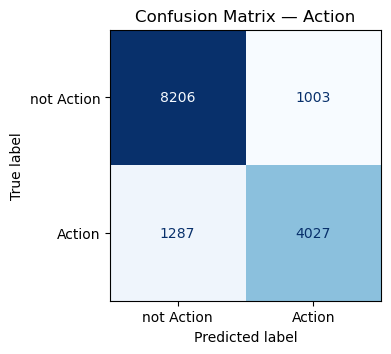

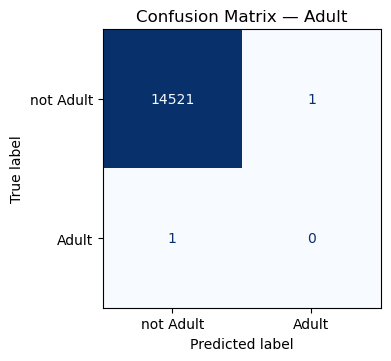

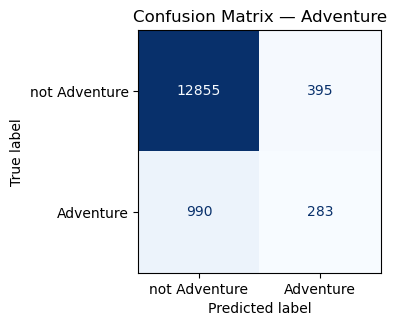

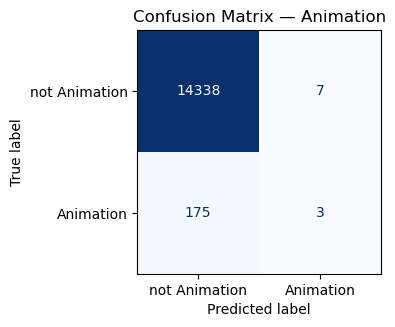

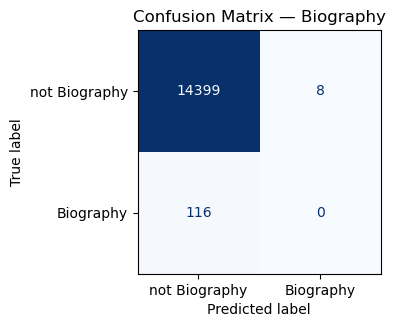

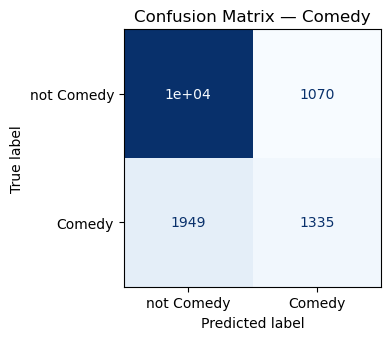

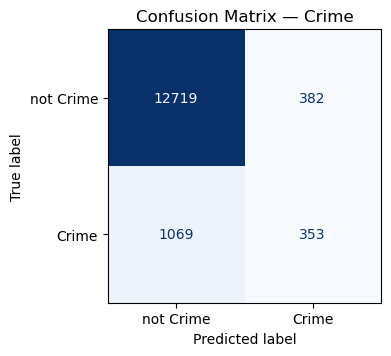

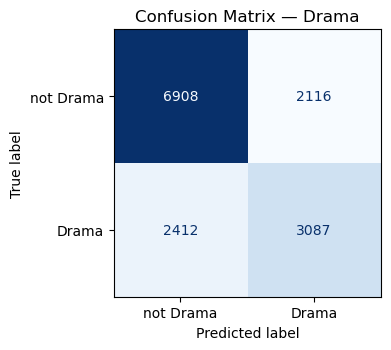

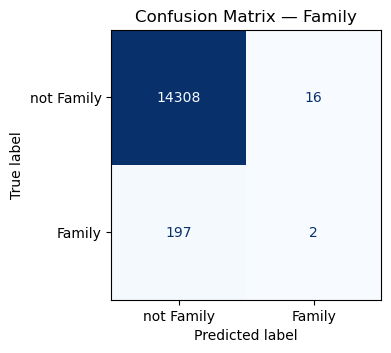

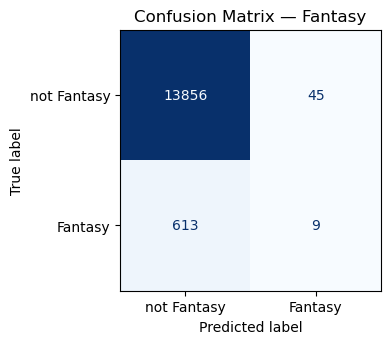

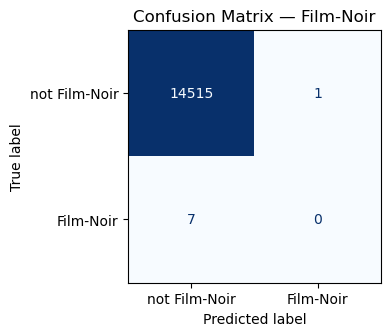

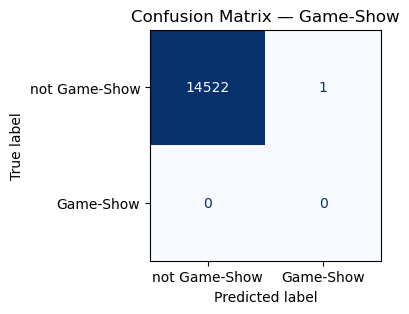

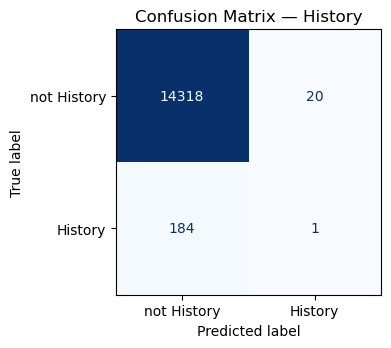

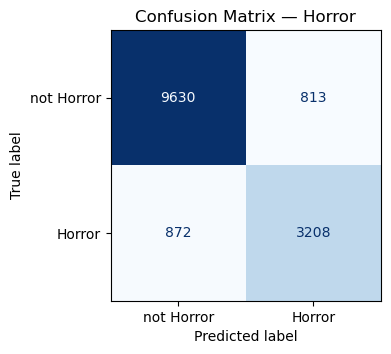

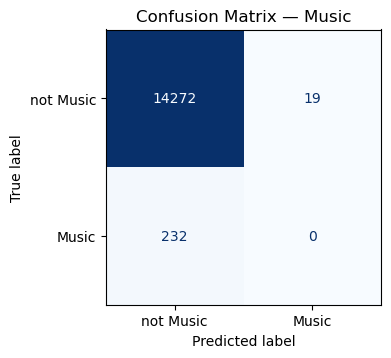

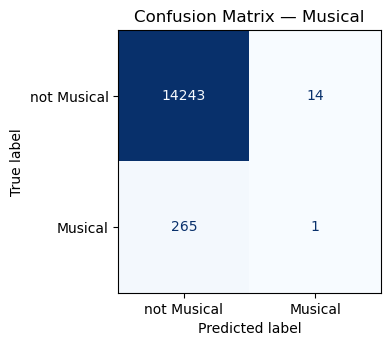

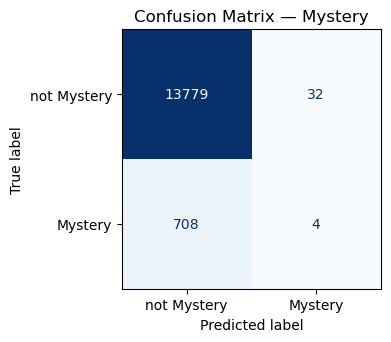

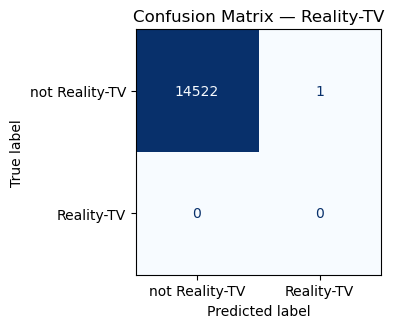

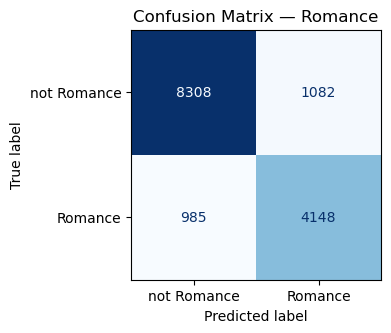

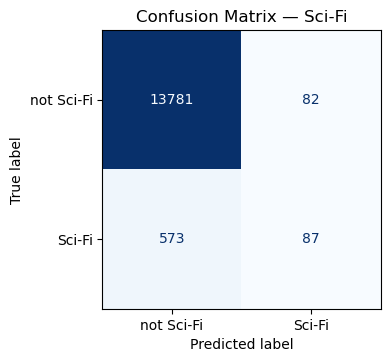

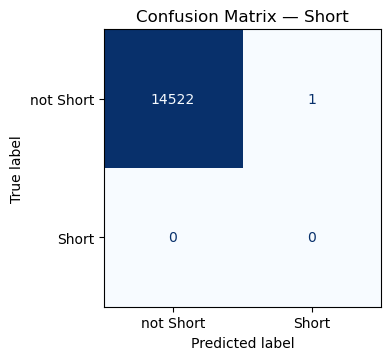

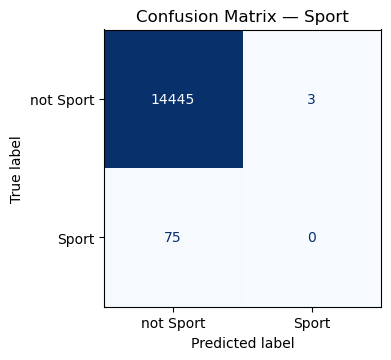

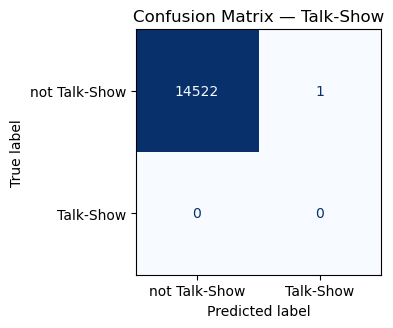

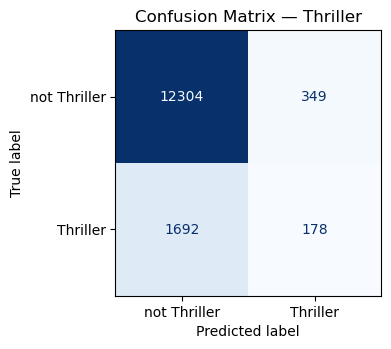

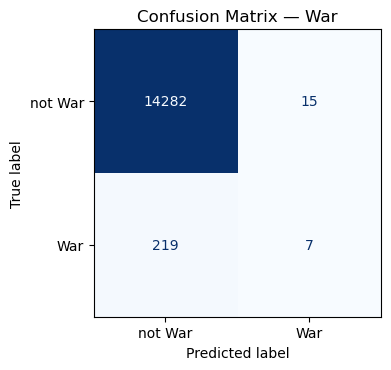

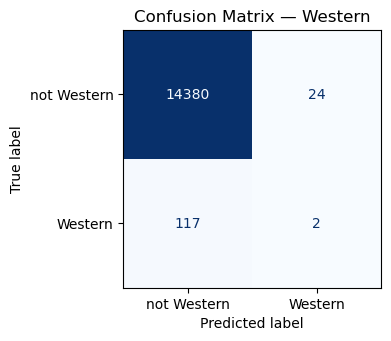

In [27]:
#Confusion matrix
plot_multilabel_conf_matrix(ml_model, X_test_raw, Y_test_sets, class_names)